# Healthcare Readmission Risk Analysis

## Overview
This project analyzes factors associated with 30-day hospital readmissions using a de-identified healthcare dataset.  
The goal is to identify patient and encounter-level predictors of readmission and evaluate a logistic regression model using ROC-AUC and accuracy metrics.

## Business Question
Which patient characteristics and healthcare utilization factors are most predictive of hospital readmission within 30 days?

In [2]:
#import packages I know I'll use for now
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Review

In [4]:
#read in our csv file 
df = pd.read_csv('medical_clean.csv')

In [5]:
#check the data
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,...,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,...,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,...,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,...,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,...,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

## Data Quality Assessment
We verified that the dataset contains no missing values across selected variables.

In [8]:
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [9]:
#check the columns we have to work with
df.columns

Index(['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State',
       'County', 'Zip', 'Lat', 'Lng', 'Population', 'Area', 'TimeZone', 'Job',
       'Children', 'Age', 'Income', 'Marital', 'Gender', 'ReAdmis',
       'VitD_levels', 'Doc_visits', 'Full_meals_eaten', 'vitD_supp',
       'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke',
       'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes',
       'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis',
       'Reflux_esophagitis', 'Asthma', 'Services', 'Initial_days',
       'TotalCharge', 'Additional_charges', 'Item1', 'Item2', 'Item3', 'Item4',
       'Item5', 'Item6', 'Item7', 'Item8'],
      dtype='object')

## Data Preparation

In [11]:
#create a new df based off our research question. 
#Can we predict whether a patient will be readmitted to the hospital within 30 days based on their health conditions and lifefstyle factors?
med_df = df[['ReAdmis','HighBlood', 'Stroke', 'Diabetes', 'Asthma', 'Overweight', 'Arthritis',
            'Hyperlipidemia', 'BackPain', 'Anxiety', 'Full_meals_eaten', 
            'Soft_drink', 'VitD_levels', 'vitD_supp', 'Doc_visits', 'Age', 
            'Gender', 'Area', 'Initial_days', 'Initial_admin', 'Services']]

In [12]:
med_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ReAdmis           10000 non-null  object 
 1   HighBlood         10000 non-null  object 
 2   Stroke            10000 non-null  object 
 3   Diabetes          10000 non-null  object 
 4   Asthma            10000 non-null  object 
 5   Overweight        10000 non-null  object 
 6   Arthritis         10000 non-null  object 
 7   Hyperlipidemia    10000 non-null  object 
 8   BackPain          10000 non-null  object 
 9   Anxiety           10000 non-null  object 
 10  Full_meals_eaten  10000 non-null  int64  
 11  Soft_drink        10000 non-null  object 
 12  VitD_levels       10000 non-null  float64
 13  vitD_supp         10000 non-null  int64  
 14  Doc_visits        10000 non-null  int64  
 15  Age               10000 non-null  int64  
 16  Gender            10000 non-null  object 

In [13]:
#Look at summary stats and prepare for visualization
med_df.describe()

,Full_meals_eaten,VitD_levels,vitD_supp,Doc_visits,Age,Initial_days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.001400,17.964262,0.398900,5.012200,53.511700,34.455299
std,1.008117,2.017231,0.628505,1.045734,20.638538,26.309341
min,0.000000,9.806483,0.000000,1.000000,18.000000,1.001981
25%,0.000000,16.626439,0.000000,4.000000,36.000000,7.896215
50%,1.000000,17.951122,0.000000,5.000000,53.000000,35.836244
75%,2.000000,19.347963,1.000000,6.000000,71.000000,61.161020
max,7.000000,26.394449,5.000000,9.000000,89.000000,71.981490


In [14]:
#I want to see the counts of these specific columns so I'm going to make them a list
columns = ['ReAdmis', 'Area', 'Initial_admin', 'Gender', 'Services','HighBlood',
           'Stroke', 'Diabetes', 'Asthma', 'Overweight', 'Arthritis','Hyperlipidemia',
           'BackPain', 'Anxiety','Soft_drink']

# Loop through each column and print the value counts
for col in columns:
    print(f"Value counts for {col}:")
    print(med_df[col].value_counts())
    print('\n')

Value counts for ReAdmis:
ReAdmis
No     6331
Yes    3669
Name: count, dtype: int64


Value counts for Area:
Area
Rural       3369
Suburban    3328
Urban       3303
Name: count, dtype: int64


Value counts for Initial_admin:
Initial_admin
Emergency Admission      5060
Elective Admission       2504
Observation Admission    2436
Name: count, dtype: int64


Value counts for Gender:
Gender
Female       5018
Male         4768
Nonbinary     214
Name: count, dtype: int64


Value counts for Services:
Services
Blood Work     5265
Intravenous    3130
CT Scan        1225
MRI             380
Name: count, dtype: int64


Value counts for HighBlood:
HighBlood
No     5910
Yes    4090
Name: count, dtype: int64


Value counts for Stroke:
Stroke
No     8007
Yes    1993
Name: count, dtype: int64


Value counts for Diabetes:
Diabetes
No     7262
Yes    2738
Name: count, dtype: int64


Value counts for Asthma:
Asthma
No     7107
Yes    2893
Name: count, dtype: int64


Value counts for Overweight:
Overweight

In [15]:
#due to settingWithCopyWarning warnings we will create a copy of our dataframe
med_df = med_df.copy()

## Exploratory Data Analysis (EDA)
We explored distributions and relationships between key variables and readmission outcomes using visualizations.

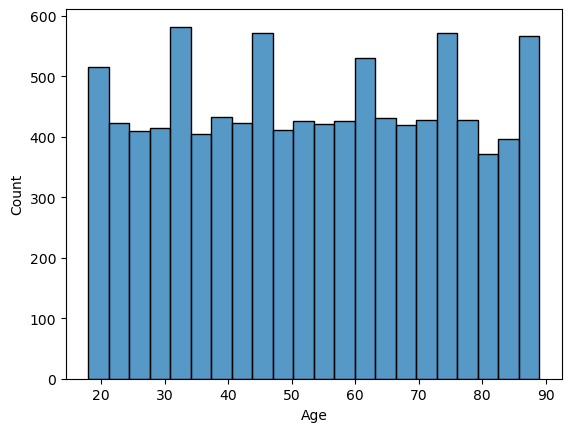

In [18]:
#univariate visualization

sns.histplot(med_df.Age)
plt.show()

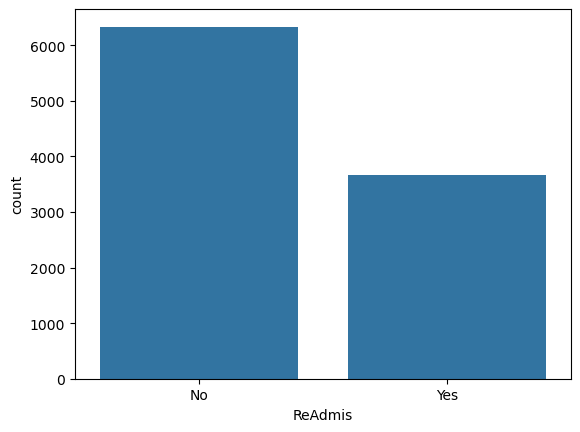

In [19]:
sns.countplot(med_df,x='ReAdmis')
plt.show()

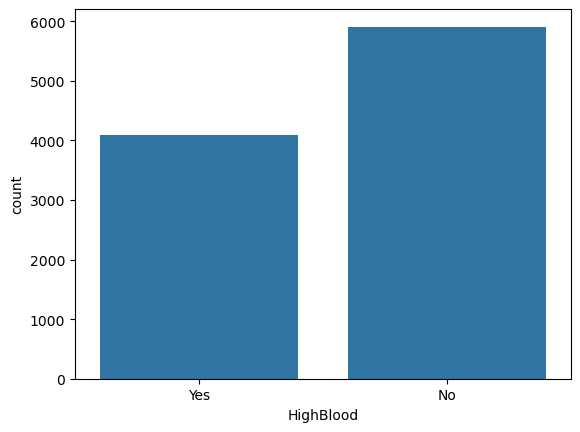

In [20]:
sns.countplot(med_df, x='HighBlood')
plt.show()

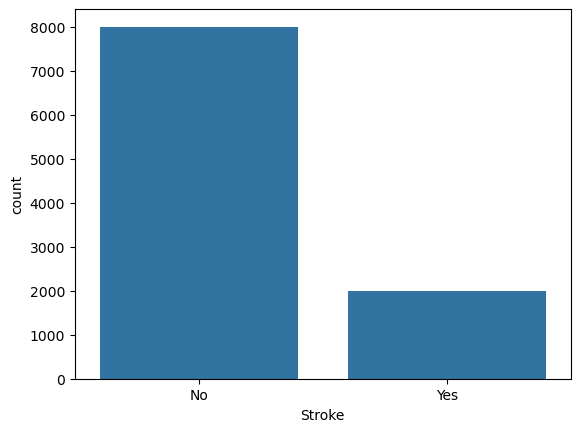

In [21]:
sns.countplot(med_df, x='Stroke')
plt.show()

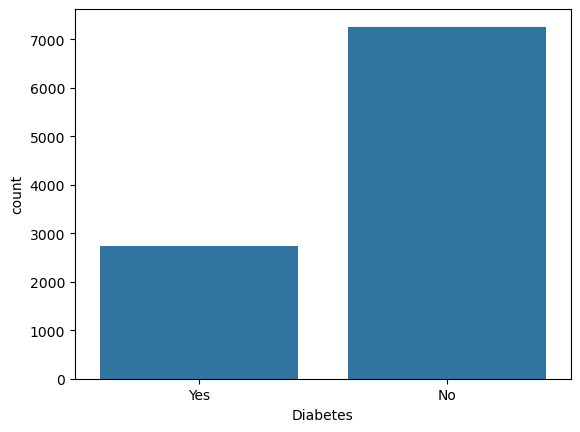

In [22]:
sns.countplot(med_df, x='Diabetes')
plt.show()

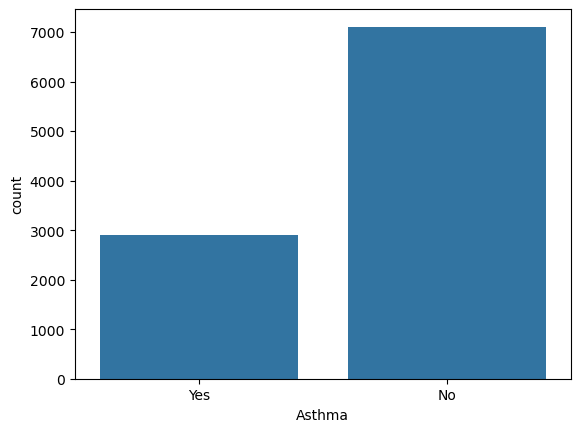

In [23]:
sns.countplot(med_df, x='Asthma')
plt.show()

### Health Conditions and Readmission

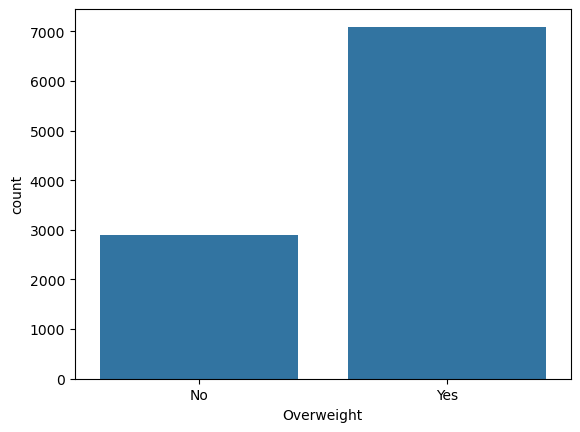

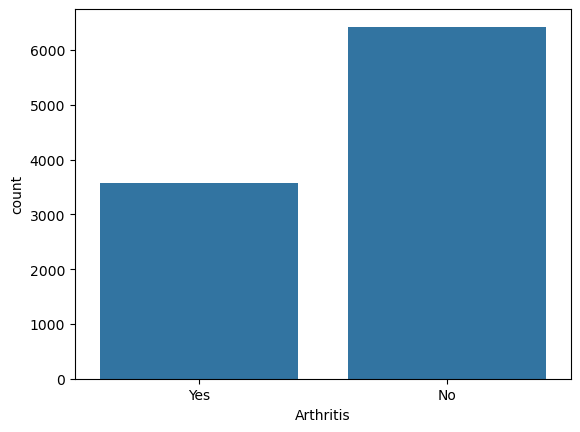

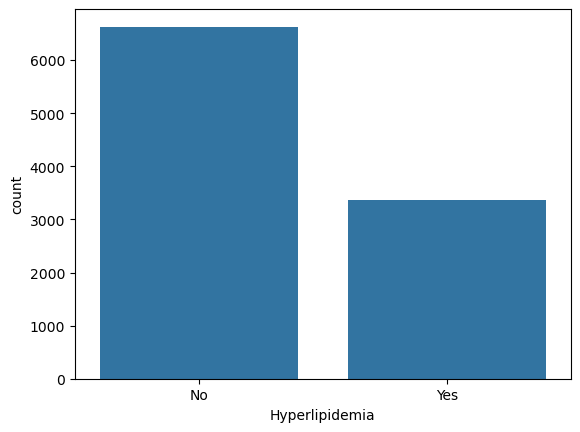

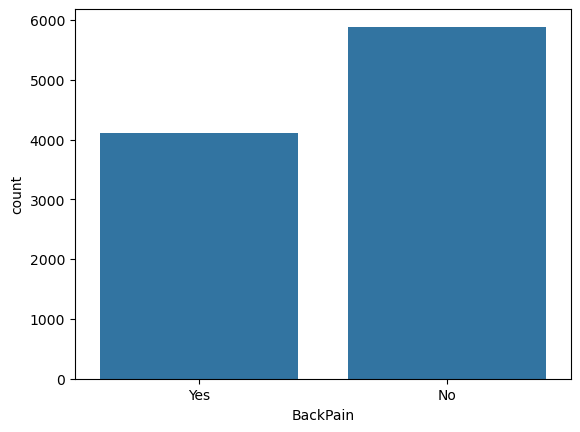

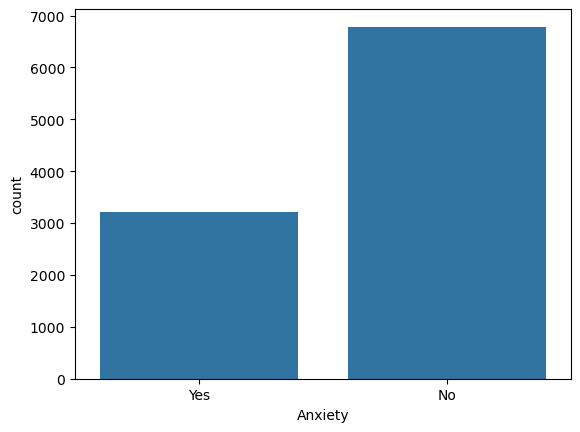

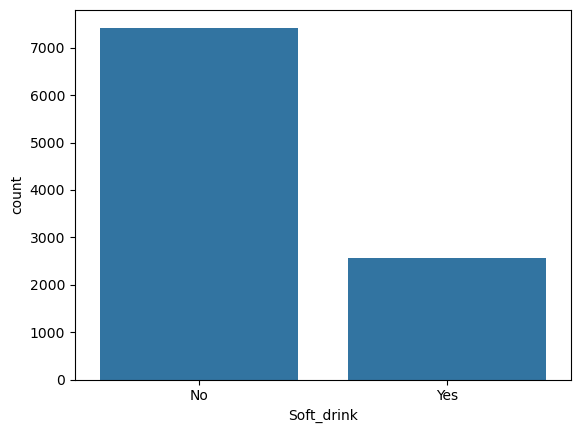

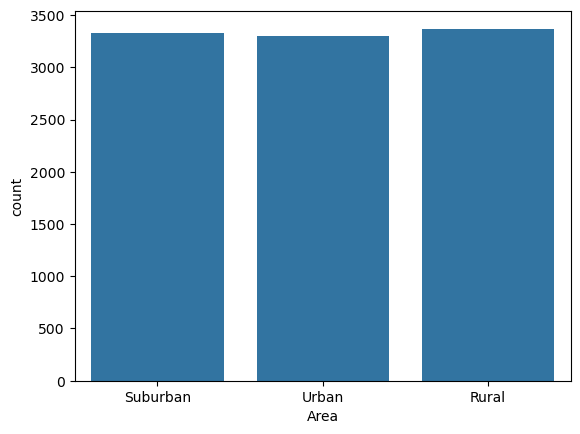

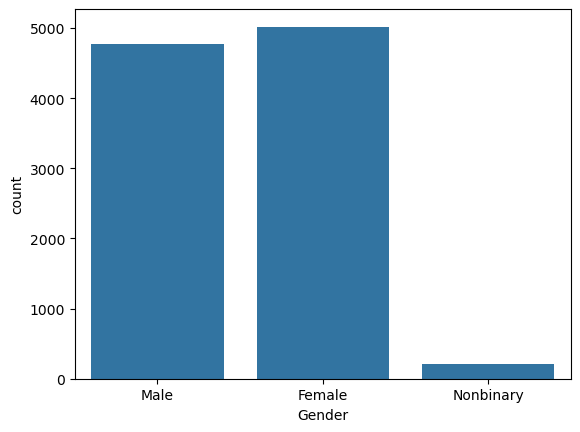

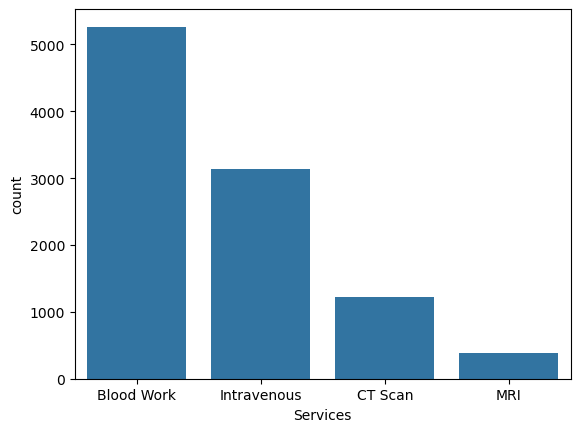

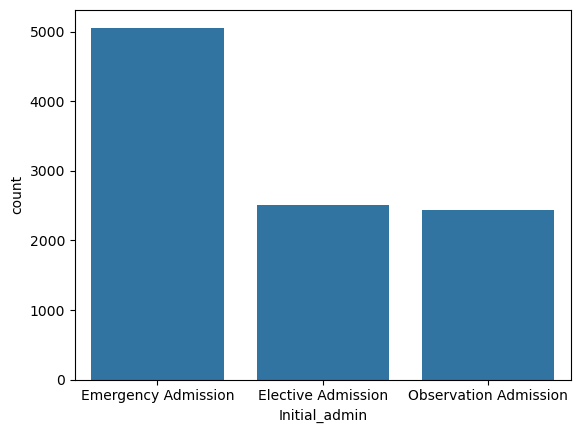

In [25]:
sns.countplot(med_df, x='Overweight')
plt.show()

sns.countplot(med_df, x='Arthritis')
plt.show()

sns.countplot(med_df, x='Hyperlipidemia')
plt.show()

sns.countplot(med_df, x='BackPain')
plt.show()

sns.countplot(med_df, x='Anxiety')
plt.show()

sns.countplot(med_df, x='Soft_drink')
plt.show()

sns.countplot(med_df, x='Area')
plt.show()

sns.countplot(med_df, x='Gender')
plt.show()

sns.countplot(med_df, x='Services')
plt.show()

sns.countplot(med_df, x='Initial_admin')
plt.show()

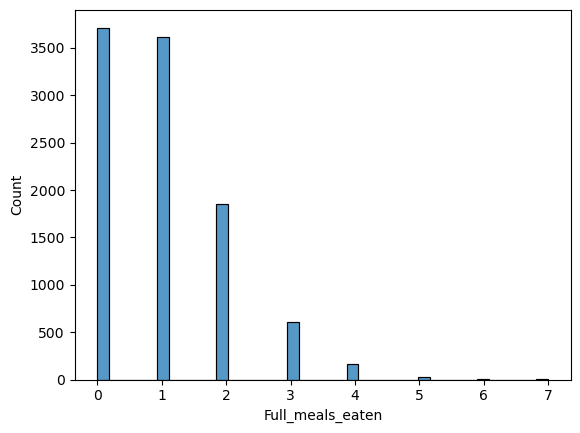

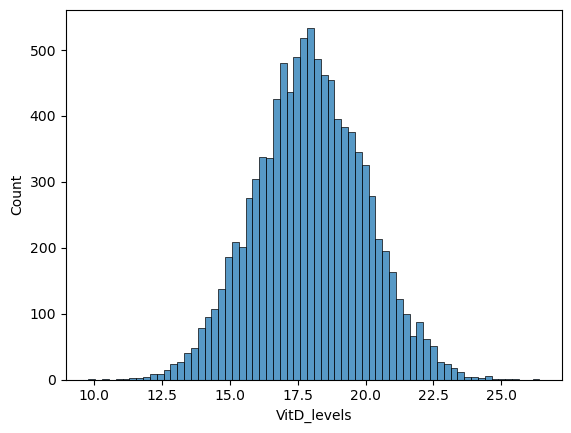

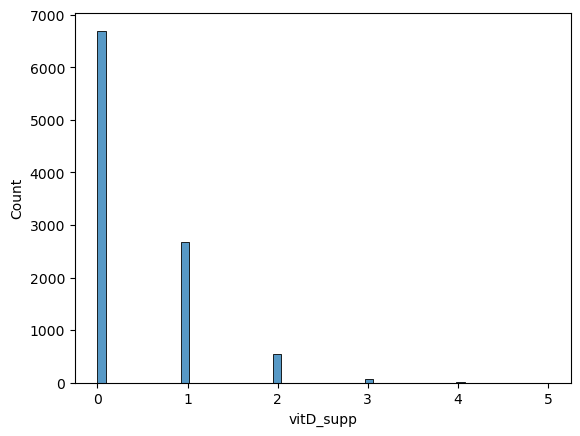

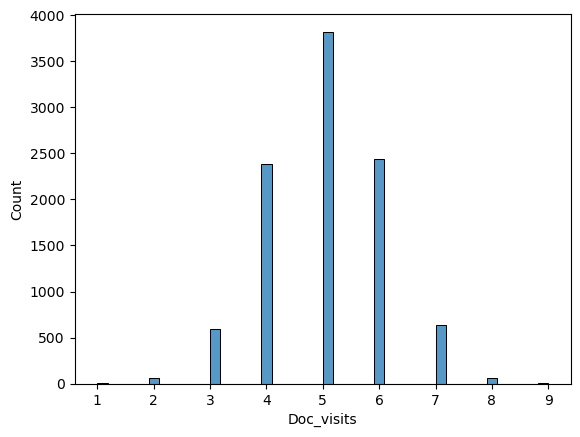

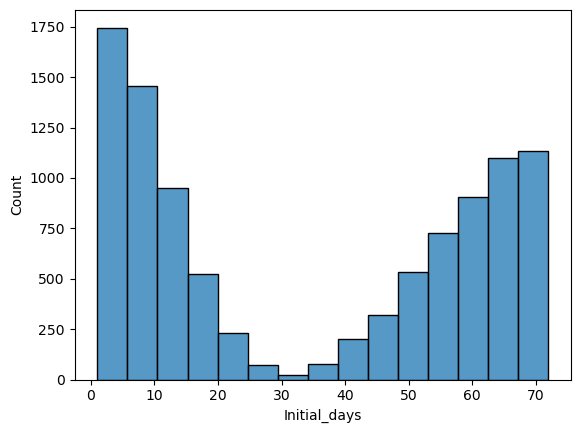

In [26]:
sns.histplot(med_df.Full_meals_eaten)
plt.show()

sns.histplot(med_df.VitD_levels)
plt.show()

sns.histplot(med_df.vitD_supp)
plt.show()

sns.histplot(med_df.Doc_visits)
plt.show()

sns.histplot(med_df.Initial_days)
plt.show()

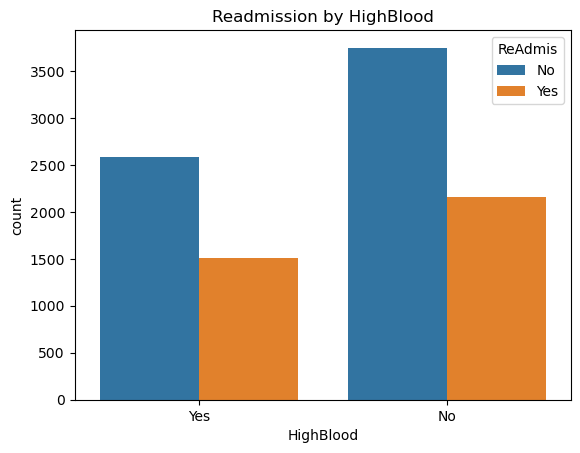

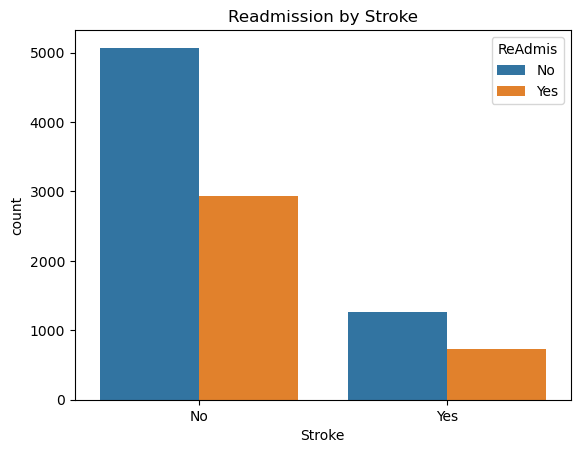

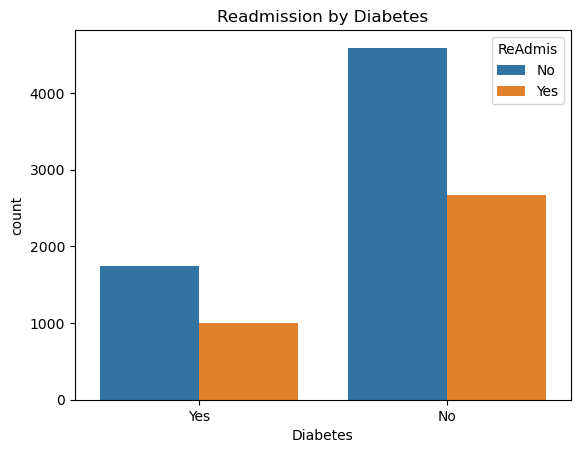

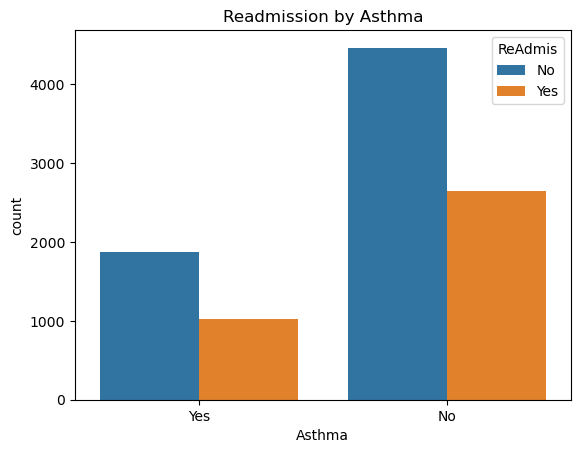

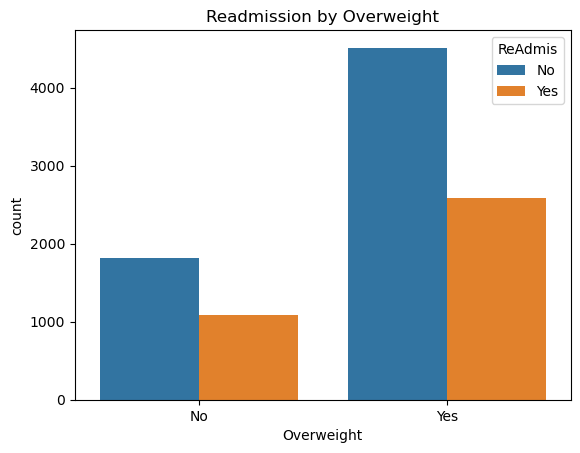

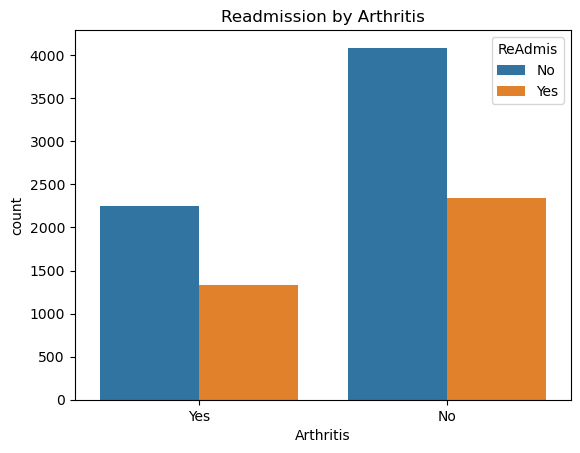

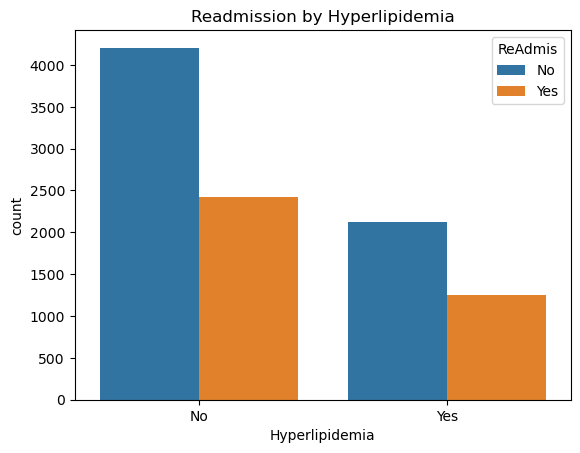

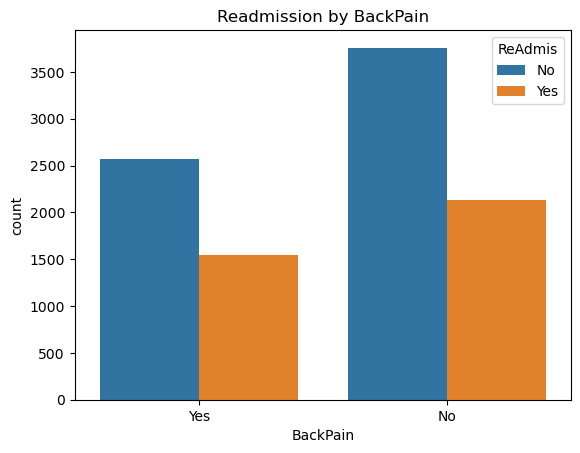

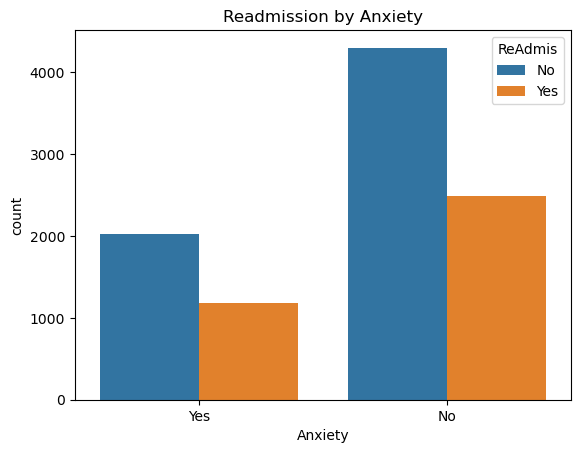

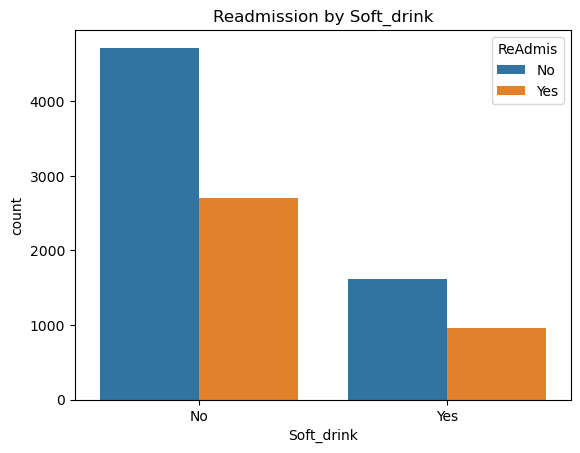

In [27]:
#separate some of the independent variables for visualization
health_conditions = ['HighBlood', 'Stroke', 'Diabetes', 'Asthma', 'Overweight', 'Arthritis', 
                     'Hyperlipidemia', 'BackPain', 'Anxiety','Soft_drink']

for condition in health_conditions:
    sns.countplot(x=condition, hue='ReAdmis', data=med_df)
    plt.title(f'Readmission by {condition}')
    plt.show()

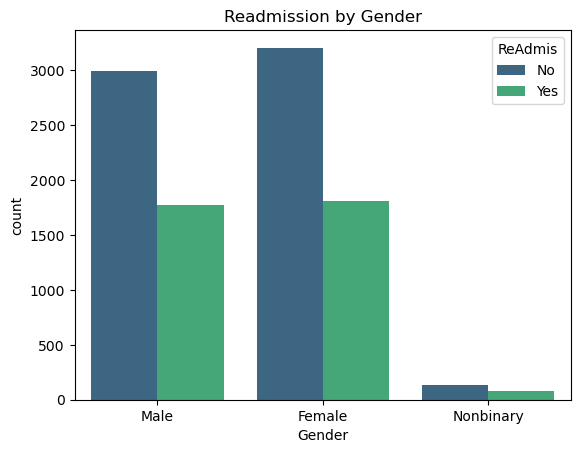

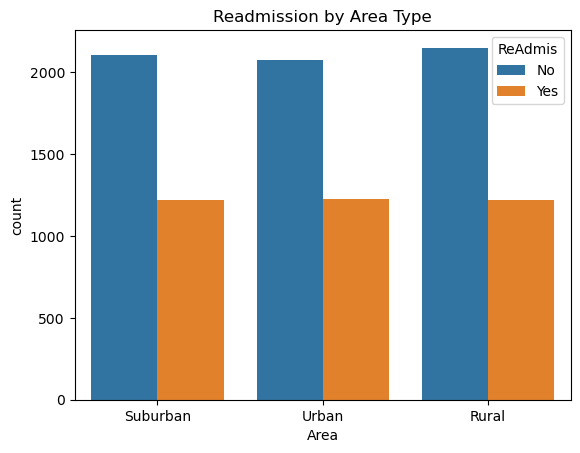

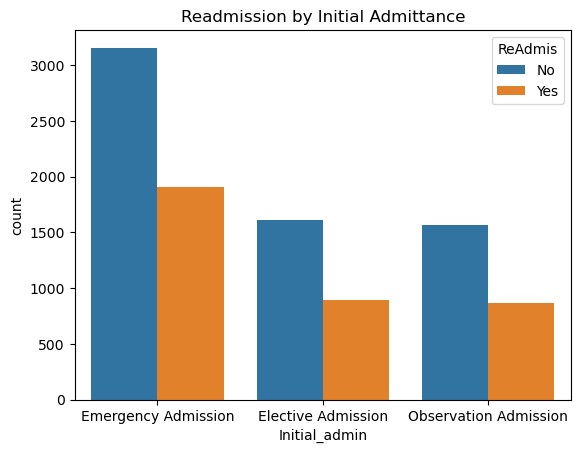

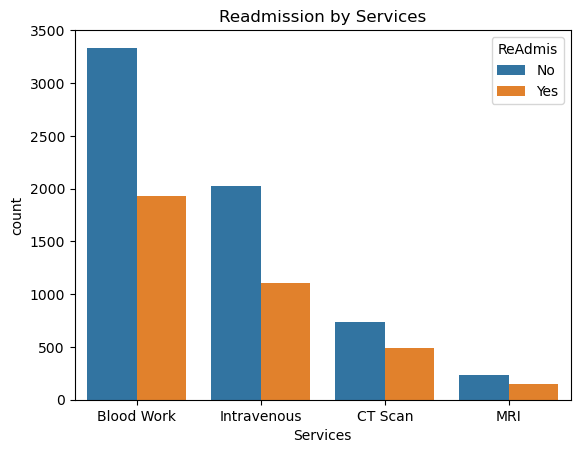

In [28]:
# Count plot for Gender vs. ReAdmis
sns.countplot(x='Gender', hue='ReAdmis', data=med_df, palette='viridis')
plt.title('Readmission by Gender')
plt.show()

# Count plot for Area vs. ReAdmis
sns.countplot(x='Area', hue='ReAdmis', data=med_df)
plt.title('Readmission by Area Type')
plt.show()

# Count plot for Initial admit vs. ReAdmis
sns.countplot(x='Initial_admin', hue='ReAdmis', data=med_df)
plt.title('Readmission by Initial Admittance')
plt.show()
# Count plot for Initial admit vs. ReAdmis
sns.countplot(x='Services', hue='ReAdmis', data=med_df)
plt.title('Readmission by Services')
plt.show()

### Numeric Variables and Outlier Detection

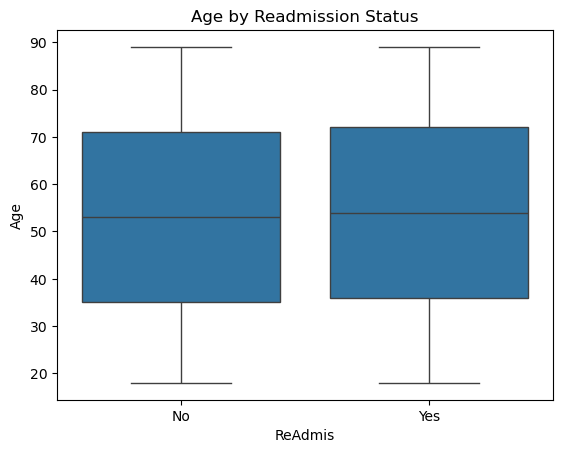

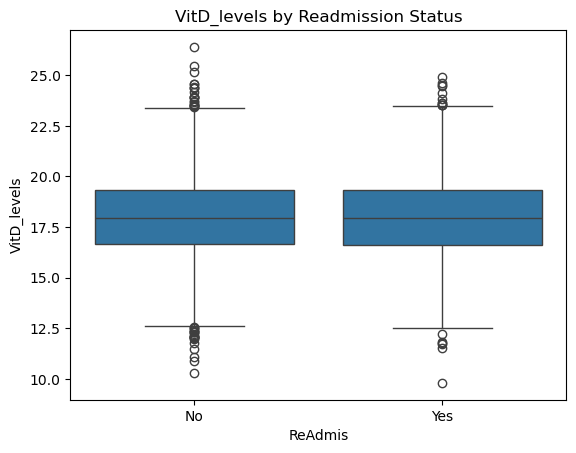

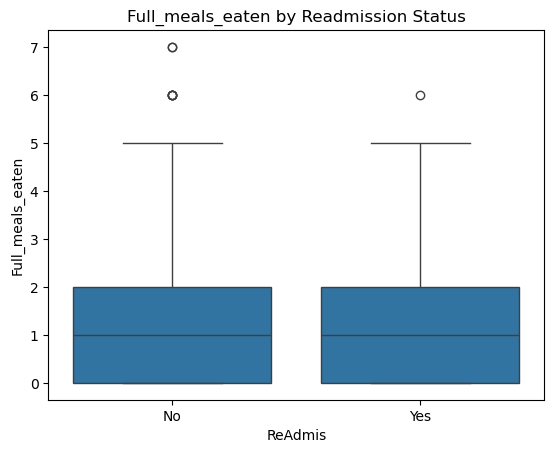

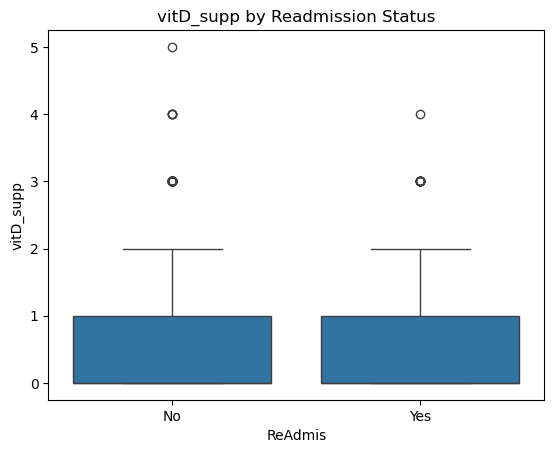

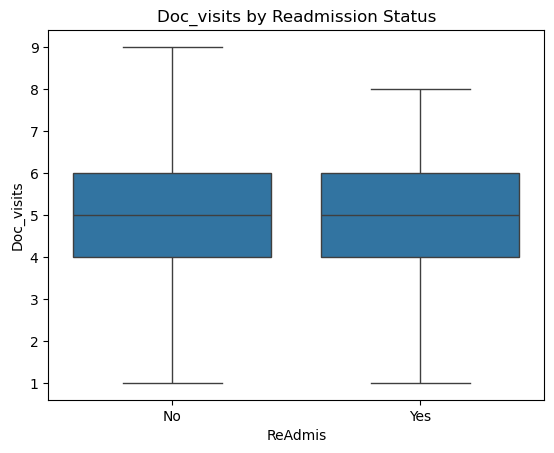

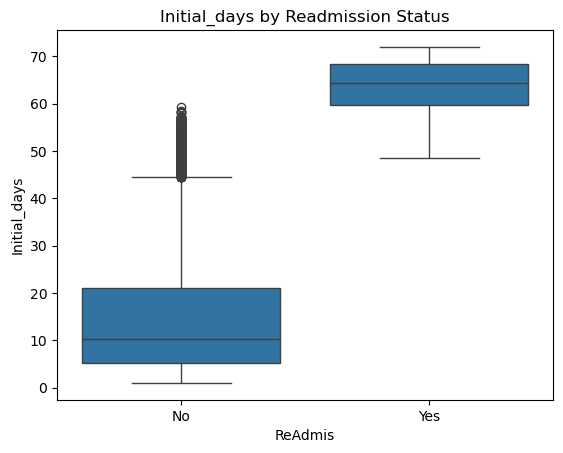

In [30]:
#separate our numeric variables for visualization
#using lists and for loops we can create multiple visualizations in one action

numeric_vars = ['Age', 'VitD_levels', 'Full_meals_eaten', 'vitD_supp', 'Doc_visits', 'Initial_days']

for var in numeric_vars:
    sns.boxplot(x='ReAdmis', y=var, data=med_df)
    plt.title(f'{var} by Readmission Status')
    plt.show()

We can see from our visualization that we have some outliers in vitD_supp, Full_meals_eaten, Initial_days, and VitD_levels. We are going to winsorize them so as not to overfit our model to extreme values. 

## Outlier Treatment
Several numeric variables exhibited extreme values. Winsorization was applied to reduce the influence of outliers while preserving overall distributions.

In [33]:
#import winsorize from scipy library
from scipy.stats.mstats import winsorize

# Apply Winsorizing (limit the top and bottom 1%)
med_df['vitD_supp'] = winsorize(med_df['vitD_supp'], limits=[0.01, 0.01])
med_df['Full_meals_eaten'] = winsorize(med_df['Full_meals_eaten'], limits=[0.01, 0.01])
med_df['Initial_days'] = winsorize(med_df['Initial_days'], limits=[0.01, 0.01])
med_df['VitD_levels'] = winsorize(med_df['VitD_levels'], limits=[0.01, 0.01])


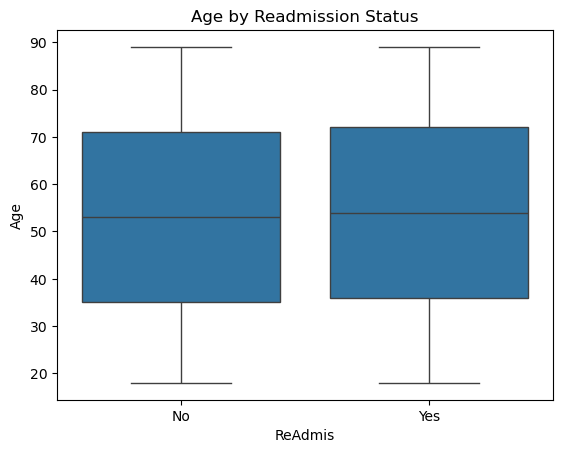

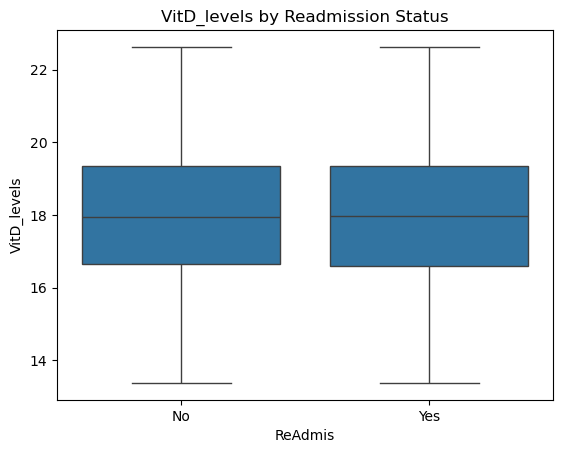

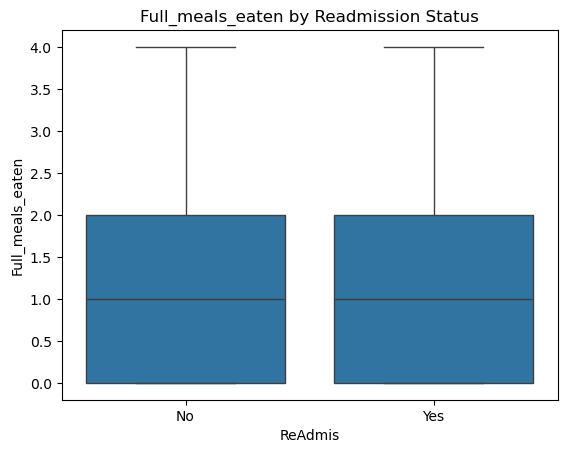

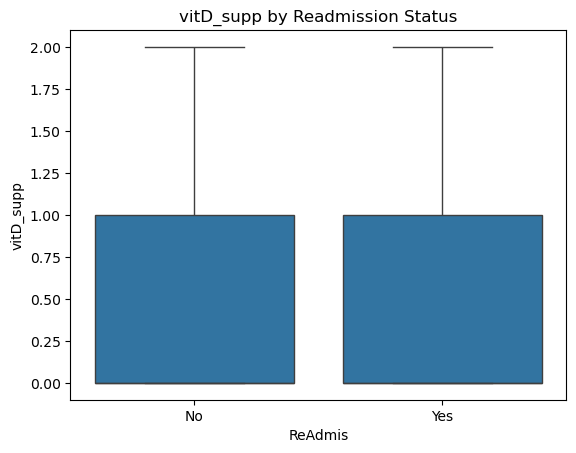

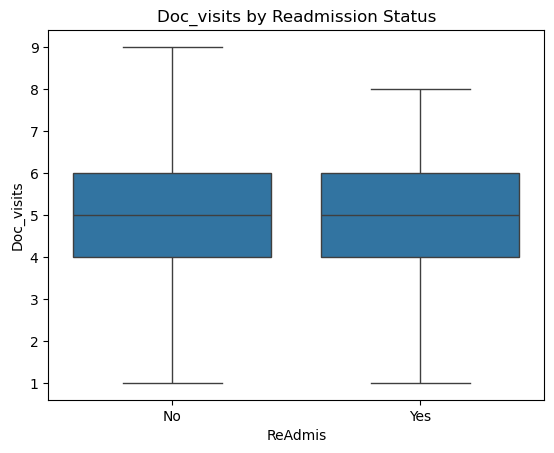

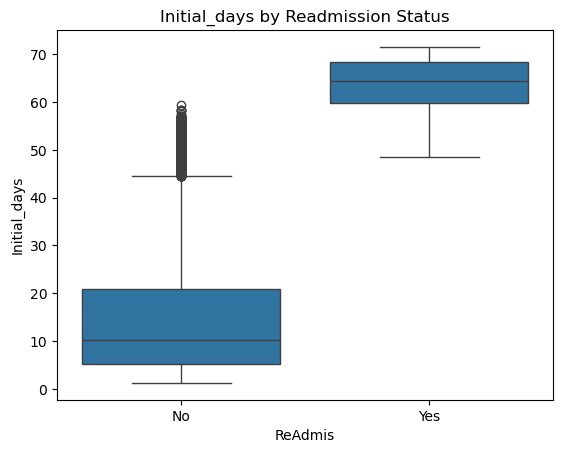

In [34]:
#rerun the boxplots to check the outliers
for var in numeric_vars:
    sns.boxplot(x='ReAdmis', y=var, data=med_df)
    plt.title(f'{var} by Readmission Status')
    plt.show()

## Data Preparation for Modeling
Categorical variables were encoded using one-hot encoding. The target variable was mapped to a binary outcome.

In [37]:
med_df_csv = pd.get_dummies(med_df, drop_first=True)

In [38]:
med_df_csv.to_csv('Final_data.csv', index=False)

In [39]:
#Define X and then use one hot encoding to turn the categorical data into numerical
X = med_df.drop('ReAdmis', axis=1)

In [40]:
X = pd.get_dummies(X, drop_first = True)

In [41]:
X.describe()

,Full_meals_eaten,VitD_levels,vitD_supp,Doc_visits,Age,Initial_days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.997100,17.963757,0.391200,5.012200,53.511700,34.454084
std,0.991862,1.980461,0.600832,1.045734,20.638538,26.304168
min,0.000000,13.381800,0.000000,1.000000,18.000000,1.253258
25%,0.000000,16.626439,0.000000,4.000000,36.000000,7.896215
50%,1.000000,17.951122,0.000000,5.000000,53.000000,35.836244
75%,2.000000,19.347963,1.000000,6.000000,71.000000,61.161020
max,4.000000,22.627210,2.000000,9.000000,89.000000,71.516650


In [42]:
#define y as our readmis but map yes to 1 and no to 0 at the same time
y = med_df.ReAdmis.map({'Yes':1, 'No':0})

In [43]:
#import our sci-kit learn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

In [44]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

## Logistic Regression Model
A logistic regression model was trained to predict 30-day readmission risk.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [47]:
log_model = LogisticRegression(max_iter=1000)

In [48]:
#Fit the model on the training data
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [49]:
#Now we will predict on the test set

pred = log_model.predict(X_test)

## Model Evaluation
Model performance was evaluated using accuracy, confusion matrix, and ROC-AUC to assess classification quality beyond simple accuracy.

[[1850   29]
 [  24 1097]]


              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1879
           1       0.97      0.98      0.98      1121

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



<function matplotlib.pyplot.show(close=None, block=None)>

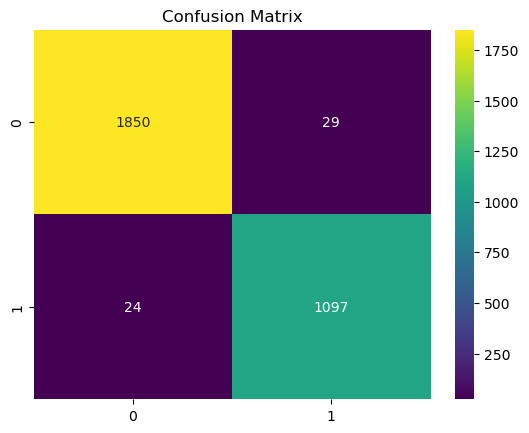

In [51]:
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

conf_matrix = confusion_matrix(y_test,pred)
sns.heatmap(conf_matrix, annot=True, fmt='d',cmap='viridis')
plt.title('Confusion Matrix')
plt.show

In [52]:
y_pred_proba = log_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.2f}')

# Accuracy
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy: {accuracy:.2f}')

ROC-AUC Score: 1.00
Accuracy: 0.98


In [54]:
# Extract feature importance (coefficients) from the initial logistic regression model
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_model.coef_[0]})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

print(feature_importance)


                                Feature  Coefficient
20    Initial_admin_Emergency Admission     1.904819
24                         Services_MRI     1.842934
5                          Initial_days     1.266000
7                            Stroke_Yes     1.154889
17                     Gender_Nonbinary     0.873507
22                     Services_CT Scan     0.712342
6                         HighBlood_Yes     0.705533
21  Initial_admin_Observation Admission     0.694399
12                   Hyperlipidemia_Yes     0.610011
18                        Area_Suburban     0.512469
8                          Diabetes_Yes     0.469387
16                          Gender_Male     0.262638
19                           Area_Urban     0.229934
13                         BackPain_Yes     0.117078
0                      Full_meals_eaten     0.079580
2                             vitD_supp     0.046451
1                           VitD_levels     0.020428
4                                   Age     0.

## Reduced Model (RFE)

In [55]:
from sklearn.feature_selection import RFE

In [56]:
#initialize the recursive feature elimination (rfe)
rfe = RFE(log_model, n_features_to_select=10)  #n_features_to_select can be changed
rfe = rfe.fit(X_train, y_train)

In [57]:
# Get the ranking of features (1 = selected feature)
ranking = pd.DataFrame({'Feature': X.columns, 'Ranking': rfe.ranking_})
print(ranking.sort_values(by='Ranking'))

                                Feature  Ranking
24                         Services_MRI        1
22                     Services_CT Scan        1
21  Initial_admin_Observation Admission        1
20    Initial_admin_Emergency Admission        1
14                          Anxiety_Yes        1
5                          Initial_days        1
6                         HighBlood_Yes        1
7                            Stroke_Yes        1
11                        Arthritis_Yes        1
9                            Asthma_Yes        1
12                   Hyperlipidemia_Yes        2
17                     Gender_Nonbinary        3
8                          Diabetes_Yes        4
18                        Area_Suburban        5
16                          Gender_Male        6
10                       Overweight_Yes        7
19                           Area_Urban        8
15                       Soft_drink_Yes        9
13                         BackPain_Yes       10
0                   

In [58]:
#get the reduced feature set
X_train_reduced = X_train[X_train.columns[rfe.support_]]
X_test_reduced = X_test[X_test.columns[rfe.support_]]


In [59]:
#Fit the model to the new reduced features
log_model_reduced = LogisticRegression(max_iter=1000)

In [60]:
log_model_reduced.fit(X_train_reduced,y_train)

LogisticRegression(max_iter=1000)

In [61]:
#predict on the test set
y_pred_reduced = log_model_reduced.predict(X_test_reduced)

Reduced Model ROC-AUC Score: 1.00
Reduced Model Accuracy: 0.99


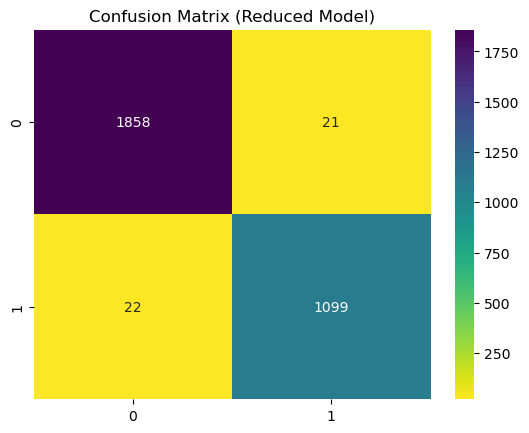

Classification Report (Reduced Model):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1879
           1       0.98      0.98      0.98      1121

    accuracy                           0.99      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [62]:
y_pred_proba_reduced = log_model_reduced.predict_proba(X_test_reduced)[:,1]
roc_auc_reduced = roc_auc_score(y_test, y_pred_proba_reduced)
accuracy_reduced = accuracy_score(y_test, y_pred_reduced)

# Print evaluation metrics
print(f'Reduced Model ROC-AUC Score: {roc_auc_reduced:.2f}')
print(f'Reduced Model Accuracy: {accuracy_reduced:.2f}')


# Confusion Matrix
conf_matrix_reduced = confusion_matrix(y_test, y_pred_reduced)
sns.heatmap(conf_matrix_reduced, annot=True, fmt='d', cmap='viridis_r')
plt.title('Confusion Matrix (Reduced Model)')
plt.show()

# Classification Report
print("Classification Report (Reduced Model):")
print(classification_report(y_test, y_pred_reduced))

## Model Interpretation
Exponentiated coefficients (odds ratios) were used to interpret the impact of key predictors on readmission likelihood.
Values greater than 1 indicate increased readmission odds; values below 1 indicate reduced risk.

In [64]:
feature_names = X_train_reduced.columns

#extract coefficients from the reduced model
coefficients = log_model_reduced.coef_[0]

coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

#print coefficients
print(coeff_df)

                               Feature  Coefficient
0                         Initial_days     1.229708
1                        HighBlood_Yes     0.671278
2                           Stroke_Yes     1.130784
3                           Asthma_Yes    -0.977581
4                        Arthritis_Yes    -0.869201
5                          Anxiety_Yes    -0.850637
6    Initial_admin_Emergency Admission     1.930682
7  Initial_admin_Observation Admission     0.748292
8                     Services_CT Scan     0.702989
9                         Services_MRI     1.867986


In [65]:
init_da = np.exp(1.229708)
print(f'Initial Days probability {init_da}')

High_blood = np.exp(.671279)
print(f'High Blood probability {High_blood}')

stroke_prob = np.exp(1.130784)
print(f'Stroke Probability {stroke_prob}')

asthma_prob = np.exp(-0.977581)
print(f'Asthma Probability {asthma_prob}')

arth_prob = np.exp(-0.869201)
print(f'Arthritis Probability {arth_prob}')

anx_prob = np.exp(-0.850637)
print(f'Anxiety Probability {anx_prob}')

init_admin_prob = np.exp(1.930682)
print(f'Emergency Admittance Probability {init_admin_prob}')

observation_prob = np.exp(.748292)
print(f'Observation Admittance Probability {observation_prob}')

ct_scan_prob = np.exp(.702989)
print(f'CT Scan Probability {ct_scan_prob}')

MRI_prob = np.exp(1.867986)
print(f'MRI Probability {MRI_prob}')

Initial Days probability 3.420230683104739
High Blood probability 1.956738389261473
Stroke Probability 3.0980844464514066
Asthma Probability 0.37622007536336805
Arthritis Probability 0.4192864253006556
Anxiety Probability 0.4271427553345304
Emergency Admittance Probability 6.8942104901686365
Observation Admittance Probability 2.113387266750961
CT Scan Probability 2.019780818837555
MRI Probability 6.475242120409935


## Key Takeaways
- Logistic regression achieved strong discrimination as measured by ROC-AUC.
- Health conditions, admission type, and utilization metrics were important predictors.
- A reduced model retained comparable performance, improving interpretability.

## Next Steps
- Evaluate alternative models (e.g., tree-based methods).
- Assess calibration and threshold optimization.
- Incorporate temporal features if available.